# 01 Dataset Audit - Bird Song Dataset

This notebook audits the Kaggle bird-song dataset before training the generative models.

Project scope used here:

- **Target species**: Northern Cardinal, Song Sparrow, American Robin
- **Raw files**: `.wav` files are expected in `bird_songs_dataset/wavfiles/`
- **Metadata**: `bird_songs_dataset/bird_songs_metadata.csv` provides `filename`, `id`, and species label in `name`
- **Important split rule**: split by original recording `id`, not by individual `filename`, to avoid train/test leakage

Main outputs of this notebook:

1. Basic metadata statistics
2. Missing-file check
3. Species and recording-ID counts
4. Duration, sample-rate, and RMS-energy checks
5. Random audio playback samples
6. Random log-mel spectrogram visualization
7. README-compatible train/validation/test manifest files

## 0. Environment setup

Run the install cell if your environment does not already have these packages.

The notebook uses:

- `pandas`, `numpy` for metadata processing
- `matplotlib` for plots
- `soundfile` for audio file info and loading
- `librosa` for resampling and log-mel spectrograms
- `scikit-learn` for group-based splitting

In [1]:
# Uncomment if needed.
# %pip install pandas numpy matplotlib soundfile librosa scikit-learn IPython

In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import soundfile as sf
import librosa
from IPython.display import Audio, display
from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1. Configure paths and target species

The default paths match the repository layout described in `README.md`. Run this notebook from the project root so `Path.cwd()` resolves to the folder containing `README.md`.

Example folder structure:

```text
project/
  README.md
  01_dataset_audit.ipynb
  manifests/
    full_dataset_manifest.csv
    full_dataset_train.csv
    full_dataset_validation.csv
    full_dataset_test.csv
  bird_songs_dataset/
    bird_songs_metadata.csv
    wavfiles/
      11713-0.wav
      11713-1.wav
      ...
```

In [3]:
# Paths are aligned with README.md.
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "bird_songs_dataset"
METADATA_CSV = DATASET_DIR / "bird_songs_metadata.csv"
AUDIO_DIR = DATASET_DIR / "wavfiles"

TARGET_SPECIES = [
    "Northern Cardinal",
    "Song Sparrow",
    "American Robin",
]

# Output files created by this notebook.
MANIFEST_OUTPUT_DIR = PROJECT_ROOT / "manifests"
MANIFEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset folder:", DATASET_DIR.resolve())
print("Metadata path:", METADATA_CSV.resolve())
print("Audio folder:", AUDIO_DIR.resolve())
print("Manifest output folder:", MANIFEST_OUTPUT_DIR.resolve())
print("Target species:", TARGET_SPECIES)

Project root: C:\Users\sheng\Documents\1508_project\bird_song_gen
Dataset folder: C:\Users\sheng\Documents\1508_project\bird_song_gen\bird_songs_dataset
Metadata path: C:\Users\sheng\Documents\1508_project\bird_song_gen\bird_songs_dataset\bird_songs_metadata.csv
Audio folder: C:\Users\sheng\Documents\1508_project\bird_song_gen\bird_songs_dataset\wavfiles
Manifest output folder: C:\Users\sheng\Documents\1508_project\bird_song_gen\manifests
Target species: ['Northern Cardinal', 'Song Sparrow', 'American Robin']


## 2. Load metadata and filter to selected species

In [4]:
df_all = pd.read_csv(METADATA_CSV)

print("Full metadata shape:", df_all.shape)
display(df_all.head())
print("Columns:")
print(df_all.columns.tolist())

Full metadata shape: (5422, 18)


,id,genus,species,subspecies,name,recordist,country,location,latitude,longitude,altitude,sound_type,source_url,license,time,date,remarks,filename
0,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-0.wav
1,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-1.wav
2,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-4.wav
3,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-5.wav
4,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-6.wav


Columns:
['id', 'genus', 'species', 'subspecies', 'name', 'recordist', 'country', 'location', 'latitude', 'longitude', 'altitude', 'sound_type', 'source_url', 'license', 'time', 'date', 'remarks', 'filename']


In [5]:
required_cols = {"id", "name", "filename"}
missing_cols = required_cols - set(df_all.columns)
if missing_cols:
    raise ValueError(f"Missing required metadata columns: {missing_cols}")

missing_species = set(TARGET_SPECIES) - set(df_all["name"].dropna().unique())
if missing_species:
    raise ValueError(f"Target species not found in metadata: {sorted(missing_species)}")

df = df_all[df_all["name"].isin(TARGET_SPECIES)].copy()
df = df.reset_index(drop=True)

# Add README-compatible relative paths, local full paths, and label IDs.
species_to_label = {species: i for i, species in enumerate(TARGET_SPECIES)}
label_to_species = {i: species for species, i in species_to_label.items()}

df["label_id"] = df["name"].map(species_to_label)
df["species_slug"] = (
    df["name"]
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
df["relative_wav_path"] = df["filename"].apply(lambda x: (Path("wavfiles") / x).as_posix())
df["path"] = df["relative_wav_path"].apply(lambda x: DATASET_DIR / x)

print("Filtered metadata shape:", df.shape)
print("Species to label mapping:")
print(species_to_label)
display(df[["id", "name", "label_id", "filename", "relative_wav_path", "path"]].head())

Filtered metadata shape: (3347, 22)
Species to label mapping:
{'Northern Cardinal': 0, 'Song Sparrow': 1, 'American Robin': 2}


,id,name,label_id,filename,relative_wav_path,path
0,564545,American Robin,2,564545-0.wav,wavfiles/564545-0.wav,c:\Users\sheng\Documents\1508_project\bird_son...
1,564545,American Robin,2,564545-4.wav,wavfiles/564545-4.wav,c:\Users\sheng\Documents\1508_project\bird_son...
2,564545,American Robin,2,564545-5.wav,wavfiles/564545-5.wav,c:\Users\sheng\Documents\1508_project\bird_son...
3,564545,American Robin,2,564545-6.wav,wavfiles/564545-6.wav,c:\Users\sheng\Documents\1508_project\bird_son...
4,564545,American Robin,2,564545-7.wav,wavfiles/564545-7.wav,c:\Users\sheng\Documents\1508_project\bird_son...


## 3. Basic counts

We check both clip counts and original recording counts. The `id` column should be treated as the original recording/group ID.

In [6]:
clip_counts = df["name"].value_counts().reindex(TARGET_SPECIES)
recording_counts = df.groupby("name")["id"].nunique().reindex(TARGET_SPECIES)

summary = pd.DataFrame({
    "num_clips": clip_counts,
    "num_recording_ids": recording_counts,
})
summary.loc["TOTAL"] = [df.shape[0], df["id"].nunique()]

display(summary)

,num_clips,num_recording_ids
name,,
Northern Cardinal,1074,92
Song Sparrow,1256,137
American Robin,1017,81
TOTAL,3347,310


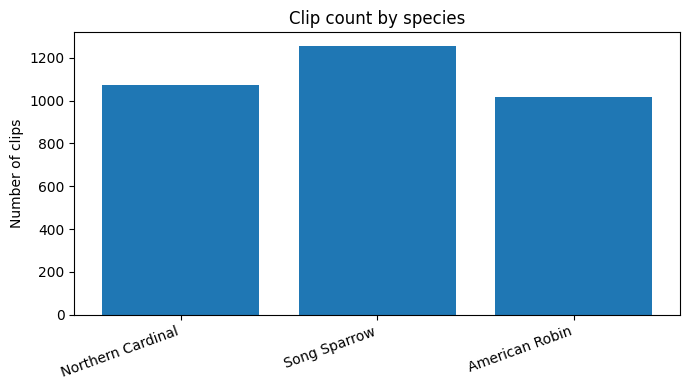

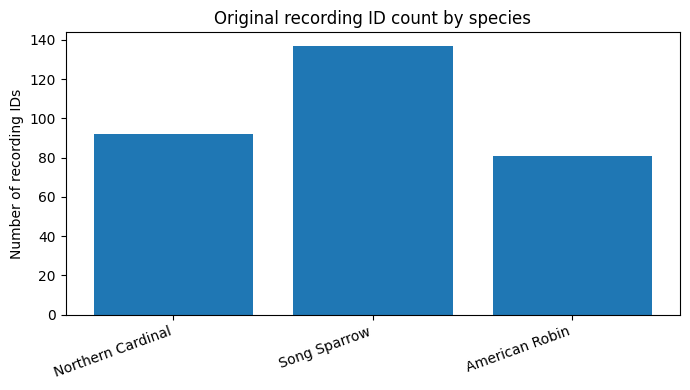

In [7]:
plt.figure(figsize=(7, 4))
plt.bar(clip_counts.index, clip_counts.values)
plt.title("Clip count by species")
plt.ylabel("Number of clips")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(recording_counts.index, recording_counts.values)
plt.title("Original recording ID count by species")
plt.ylabel("Number of recording IDs")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 4. Check whether all audio files exist

If `missing_count > 0`, check whether `AUDIO_DIR` points to `bird_songs_dataset/wavfiles/` or whether the Kaggle zip was fully extracted.

In [8]:
df["file_exists"] = df["path"].apply(lambda p: p.exists())
missing_df = df[~df["file_exists"]].copy()

print("Total selected clips:", len(df))
print("Existing files:", int(df["file_exists"].sum()))
print("Missing files:", len(missing_df))

if len(missing_df) > 0:
    display(missing_df[["id", "name", "filename", "relative_wav_path", "path"]].head(20))
else:
    print("All selected metadata filenames were found in bird_songs_dataset/wavfiles/.")

Total selected clips: 3347
Existing files: 3347
Missing files: 0
All selected metadata filenames were found in bird_songs_dataset/wavfiles/.


## 5. Audio sanity checks: duration, sample rate, channel count, RMS energy

This scans the selected files and collects basic audio statistics. If the dataset is already segmented into about 3-second clips, the duration histogram should be concentrated near 3 seconds.

In [9]:
def audio_stats(path: Path):
    # Return basic audio stats without loading the whole file.
    info = sf.info(str(path))
    duration = info.frames / info.samplerate if info.samplerate else np.nan
    return {
        "sample_rate": info.samplerate,
        "channels": info.channels,
        "frames": info.frames,
        "duration_sec": duration,
        "format": info.format,
        "subtype": info.subtype,
    }

stats_rows = []

for row in df.itertuples(index=False):
    path = Path(row.path)
    if not path.exists():
        continue
    try:
        s = audio_stats(path)
        s.update({
            "id": row.id,
            "name": row.name,
            "filename": row.filename,
        })
        stats_rows.append(s)
    except Exception as e:
        stats_rows.append({
            "id": row.id,
            "name": row.name,
            "filename": row.filename,
            "error": repr(e),
        })

stats_df = pd.DataFrame(stats_rows)
print("Stats shape:", stats_df.shape)
display(stats_df.head())

if "error" in stats_df.columns:
    bad = stats_df[stats_df["error"].notna()]
    print("Files with read errors:", len(bad))
    if len(bad) > 0:
        display(bad.head(20))

Stats shape: (3347, 9)


,sample_rate,channels,frames,duration_sec,format,subtype,id,name,filename
0,22050,1,66150,3.0,WAV,FLOAT,564545,American Robin,564545-0.wav
1,22050,1,66150,3.0,WAV,FLOAT,564545,American Robin,564545-4.wav
2,22050,1,66150,3.0,WAV,FLOAT,564545,American Robin,564545-5.wav
3,22050,1,66150,3.0,WAV,FLOAT,564545,American Robin,564545-6.wav
4,22050,1,66150,3.0,WAV,FLOAT,564545,American Robin,564545-7.wav


In [10]:
print("Sample-rate counts:")
display(stats_df["sample_rate"].value_counts().sort_index())

print("Channel-counts:")
display(stats_df["channels"].value_counts().sort_index())

print("Duration summary by species:")
display(stats_df.groupby("name")["duration_sec"].describe())

Sample-rate counts:


sample_rate
22050    3347
Name: count, dtype: int64

Channel-counts:


channels
1    3347
Name: count, dtype: int64

Duration summary by species:


,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
American Robin,1017.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0
Northern Cardinal,1074.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0
Song Sparrow,1256.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0


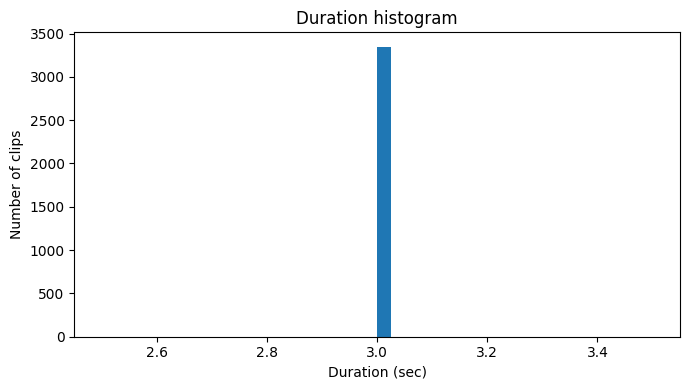

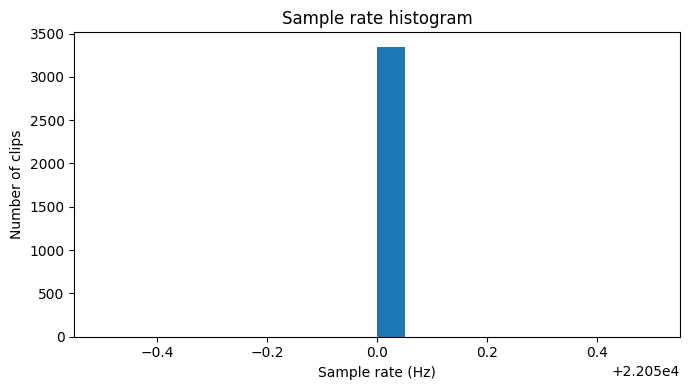

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(stats_df["duration_sec"].dropna(), bins=40)
plt.title("Duration histogram")
plt.xlabel("Duration (sec)")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(stats_df["sample_rate"].dropna(), bins=20)
plt.title("Sample rate histogram")
plt.xlabel("Sample rate (Hz)")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()

### Optional: RMS energy scan

This loads audio files, so it is slower than reading metadata. RMS energy helps identify all-silent or very low-energy clips.

In [12]:
def compute_rms(path: Path, target_sr: int = 22050):
    y, sr = librosa.load(path, sr=target_sr, mono=True)
    if len(y) == 0:
        return np.nan
    return float(np.sqrt(np.mean(y ** 2)))

rms_rows = []
for row in df.itertuples(index=False):
    path = Path(row.path)
    if not path.exists():
        continue
    try:
        rms_rows.append({
            "id": row.id,
            "name": row.name,
            "filename": row.filename,
            "rms": compute_rms(path),
        })
    except Exception as e:
        rms_rows.append({
            "id": row.id,
            "name": row.name,
            "filename": row.filename,
            "rms": np.nan,
            "error": repr(e),
        })

rms_df = pd.DataFrame(rms_rows)
display(rms_df.groupby("name")["rms"].describe())

c:\Users\sheng\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
American Robin,1017.0,0.132819,0.035007,0.043621,0.109988,0.130251,0.155270,0.389454
Northern Cardinal,1074.0,0.141051,0.045296,0.012059,0.110666,0.139557,0.170644,0.311619
Song Sparrow,1256.0,0.132038,0.041236,0.030403,0.103352,0.129322,0.156551,0.311626


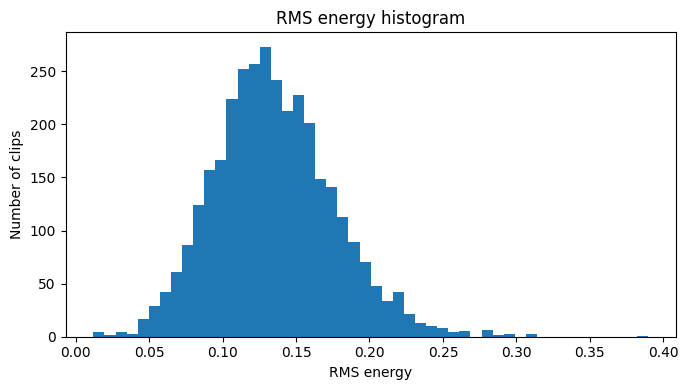

1% low-RMS threshold: 0.050611763298511504


,id,name,filename,rms
2871,317266,Northern Cardinal,317266-13.wav,0.012059
2864,317266,Northern Cardinal,317266-3.wav,0.014089
2870,317266,Northern Cardinal,317266-12.wav,0.014629
2863,317266,Northern Cardinal,317266-2.wav,0.019483
2814,325690,Northern Cardinal,325690-3.wav,0.023397
2868,317266,Northern Cardinal,317266-7.wav,0.026157
2867,317266,Northern Cardinal,317266-6.wav,0.029095
1533,320719,Song Sparrow,320719-3.wav,0.030403
2869,317266,Northern Cardinal,317266-8.wav,0.031632
1044,558357,Song Sparrow,558357-3.wav,0.032311


In [13]:
plt.figure(figsize=(7, 4))
plt.hist(rms_df["rms"].dropna(), bins=50)
plt.title("RMS energy histogram")
plt.xlabel("RMS energy")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()

# Potentially suspicious clips: very low RMS.
low_rms_threshold = rms_df["rms"].quantile(0.01)
low_rms_df = rms_df[rms_df["rms"] <= low_rms_threshold].sort_values("rms")
print("1% low-RMS threshold:", low_rms_threshold)
display(low_rms_df.head(20))

## 6. Random audio playback samples

This cell plays a few random clips per species. Use it to manually verify that the dataset is clean enough and that labels are plausible.

In [14]:
N_AUDIO_SAMPLES_PER_SPECIES = 3

for species in TARGET_SPECIES:
    print("=" * 80)
    print(species)
    species_df = df[(df["name"] == species) & (df["file_exists"])]
    sample_rows = species_df.sample(
        n=min(N_AUDIO_SAMPLES_PER_SPECIES, len(species_df)),
        random_state=RANDOM_SEED,
    )
    for _, row in sample_rows.iterrows():
        print(row["filename"], "| id:", row["id"])
        display(Audio(str(row["path"])))

Northern Cardinal
325690-4.wav | id: 325690


409009-7.wav | id: 409009


418321-0.wav | id: 418321


Song Sparrow
363142-0.wav | id: 363142


490351-10.wav | id: 490351


551290-10.wav | id: 551290


American Robin
97957-5.wav | id: 97957


564319-1.wav | id: 564319


322884-6.wav | id: 322884


## 7. Log-mel spectrogram preview

This shows random `128 Ã— 128` log-mel spectrograms. These are the main model inputs for the VAE and diffusion model.

In [15]:
# Log-mel configuration.
TARGET_SR = 22050
CLIP_DURATION_SEC = 3.0
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
SPEC_WIDTH = 128


def load_fixed_audio(path: Path, target_sr: int = TARGET_SR, duration_sec: float = CLIP_DURATION_SEC):
    # Load mono audio and pad/crop to fixed length.
    y, sr = librosa.load(path, sr=target_sr, mono=True)
    target_len = int(target_sr * duration_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y, target_sr


def logmel_128(path: Path):
    # Compute a fixed 128 x 128 log-mel spectrogram.
    y, sr = load_fixed_audio(path)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    logmel = librosa.power_to_db(mel, ref=np.max)

    # Pad/crop time axis to SPEC_WIDTH.
    if logmel.shape[1] < SPEC_WIDTH:
        logmel = np.pad(
            logmel,
            ((0, 0), (0, SPEC_WIDTH - logmel.shape[1])),
            mode="constant",
            constant_values=logmel.min(),
        )
    else:
        logmel = logmel[:, :SPEC_WIDTH]

    return logmel.astype(np.float32)

# Quick test on one file.
one_path = df[df["file_exists"]].iloc[0]["path"]
one_spec = logmel_128(one_path)
print("Example spectrogram shape:", one_spec.shape)

Example spectrogram shape: (128, 128)


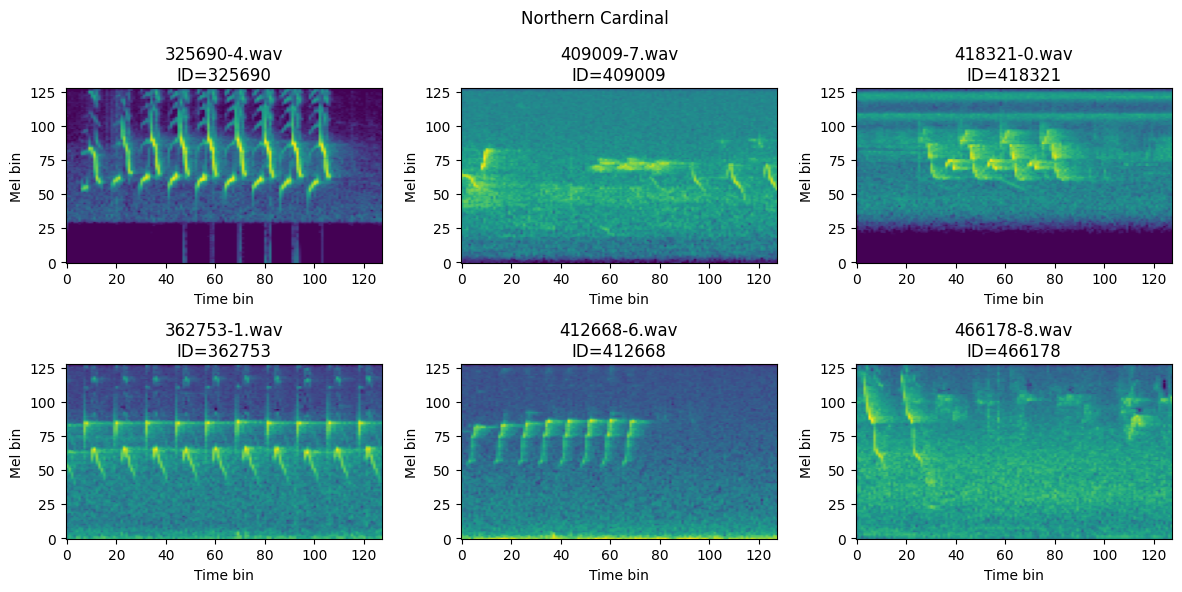

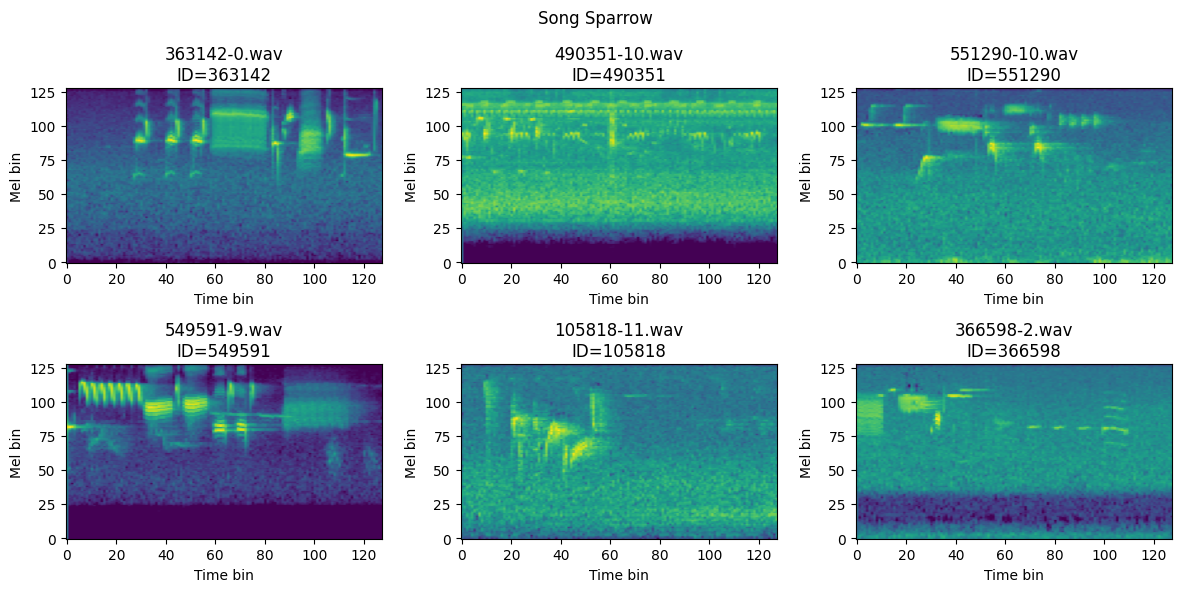

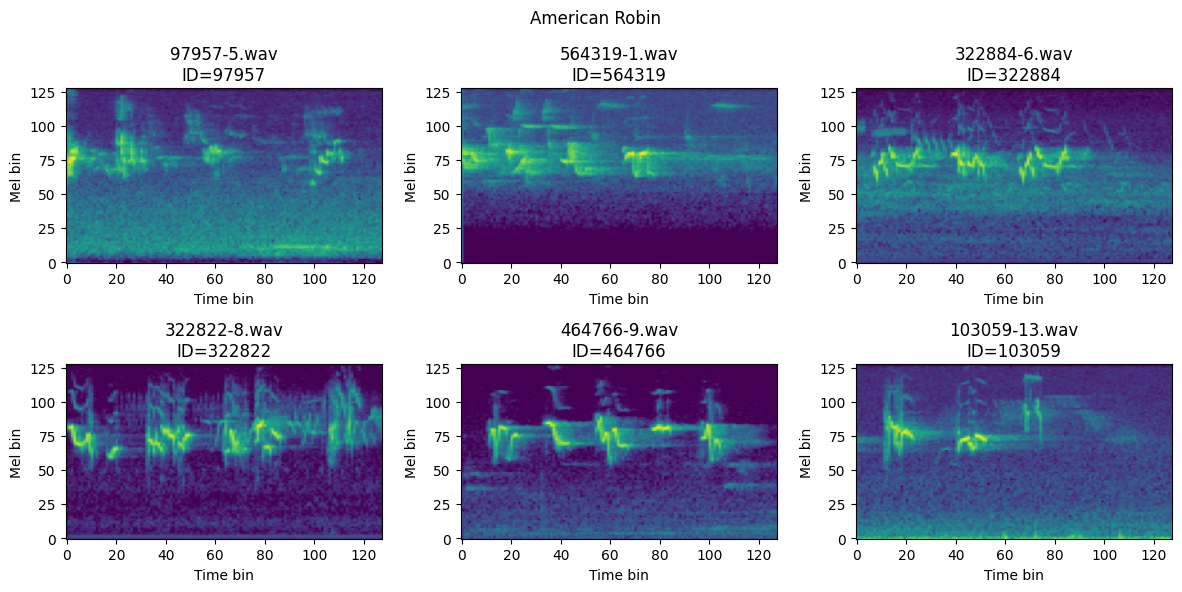

In [16]:
N_SPECTROGRAMS_PER_SPECIES = 6

for species in TARGET_SPECIES:
    species_df = df[(df["name"] == species) & (df["file_exists"])]
    sample_rows = species_df.sample(
        n=min(N_SPECTROGRAMS_PER_SPECIES, len(species_df)),
        random_state=RANDOM_SEED,
    )

    n = len(sample_rows)
    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 3))

    for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
        spec = logmel_128(row["path"])
        ax = plt.subplot(rows, cols, i)
        ax.imshow(spec, aspect="auto", origin="lower")
        ax.set_title(f'{row["filename"]}\nID={row["id"]}')
        ax.set_xlabel("Time bin")
        ax.set_ylabel("Mel bin")

    plt.suptitle(species)
    plt.tight_layout()
    plt.show()

## 8. Group-based train/validation/test split

We split by original recording `id`, not by clip filename.

This prevents leakage such as `11713-0.wav` appearing in training while `11713-1.wav` appears in testing.

In [17]:
def group_split(df_in, train_size=0.70, val_size=0.15, test_size=0.15, seed=42):
    # Group split by `id`, approximately train/val/test by clip count.
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size + val_size + test_size must equal 1.0")

    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    train_idx, temp_idx = next(gss1.split(df_in, groups=df_in["id"]))

    train_df = df_in.iloc[train_idx].copy()
    temp_df = df_in.iloc[temp_idx].copy()

    val_fraction_of_temp = val_size / (val_size + test_size)
    gss2 = GroupShuffleSplit(n_splits=1, train_size=val_fraction_of_temp, random_state=seed)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["id"]))

    val_df = temp_df.iloc[val_idx].copy()
    test_df = temp_df.iloc[test_idx].copy()

    return train_df, val_df, test_df


def split_summary(train_df, val_df, test_df):
    rows = []
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        for species in TARGET_SPECIES:
            sub = split_df[split_df["name"] == species]
            rows.append({
                "split": split_name,
                "species": species,
                "num_clips": len(sub),
                "num_recording_ids": sub["id"].nunique(),
            })
    return pd.DataFrame(rows)

train_df, val_df, test_df = group_split(df, seed=RANDOM_SEED)
summary_split = split_summary(train_df, val_df, test_df)
display(summary_split)

print("Total clips by split:")
print({
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df),
})

print("Total recording IDs by split:")
print({
    "train": train_df["id"].nunique(),
    "val": val_df["id"].nunique(),
    "test": test_df["id"].nunique(),
})

,split,species,num_clips,num_recording_ids
0,train,Northern Cardinal,756,65
1,train,Song Sparrow,872,95
2,train,American Robin,721,57
3,val,Northern Cardinal,169,14
4,val,Song Sparrow,182,19
5,val,American Robin,160,13
6,test,Northern Cardinal,149,13
7,test,Song Sparrow,202,23
8,test,American Robin,136,11


Total clips by split:
{'train': 2349, 'val': 511, 'test': 487}
Total recording IDs by split:
{'train': 217, 'val': 46, 'test': 47}


In [18]:
# Verify that no original recording ID appears in more than one split.
train_ids = set(train_df["id"])
val_ids = set(val_df["id"])
test_ids = set(test_df["id"])

print("train âˆ© val:", len(train_ids & val_ids))
print("train âˆ© test:", len(train_ids & test_ids))
print("val âˆ© test:", len(val_ids & test_ids))

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0
print("No recording-ID leakage detected.")

train âˆ© val: 0
train âˆ© test: 0
val âˆ© test: 0
No recording-ID leakage detected.


### Optional: try multiple random seeds and choose a more balanced split

Because the split is group-based, exact class balance is not guaranteed. The cell below searches several seeds and chooses the one with the lowest species-balance error.

In [19]:
def balance_score(train_df, val_df, test_df):
    # Lower is better. Measures how far split species proportions are from full-dataset proportions.
    full_props = df["name"].value_counts(normalize=True).reindex(TARGET_SPECIES).fillna(0)
    score = 0.0
    for split_df in [train_df, val_df, test_df]:
        props = split_df["name"].value_counts(normalize=True).reindex(TARGET_SPECIES).fillna(0)
        score += float(np.abs(props - full_props).sum())
    return score

best = None
for seed in range(100):
    tr, va, te = group_split(df, seed=seed)
    score = balance_score(tr, va, te)
    if best is None or score < best[0]:
        best = (score, seed, tr, va, te)

best_score, best_seed, train_df, val_df, test_df = best
print("Best seed:", best_seed)
print("Best balance score:", best_score)
display(split_summary(train_df, val_df, test_df))

Best seed: 7
Best balance score: 0.0727610404937839


,split,species,num_clips,num_recording_ids
0,train,Northern Cardinal,740,63
1,train,Song Sparrow,890,98
2,train,American Robin,709,56
3,val,Northern Cardinal,172,15
4,val,Song Sparrow,184,18
5,val,American Robin,163,13
6,test,Northern Cardinal,162,14
7,test,Song Sparrow,182,21
8,test,American Robin,145,12


## 9. Save manifest files

These CSVs are the README-compatible manifests to use in later notebooks/scripts. They store WAV locations as paths relative to `bird_songs_dataset/`, for example `wavfiles/70119-0.wav`.

In [20]:
def prepare_manifest(split_df, split_name):
    out = split_df.copy()
    out["split"] = split_name
    cols = [
        "split", "name", "species_slug", "genus", "species", "id", "filename",
        "relative_wav_path", "source_url", "license", "recordist", "date", "sound_type",
    ]
    cols = [c for c in cols if c in out.columns]
    return out[cols].sort_values(["name", "id", "filename"]).reset_index(drop=True)

train_manifest = prepare_manifest(train_df, "train")
val_manifest = prepare_manifest(val_df, "validation")
test_manifest = prepare_manifest(test_df, "test")
full_manifest = pd.concat([train_manifest, val_manifest, test_manifest], ignore_index=True)

full_path = MANIFEST_OUTPUT_DIR / "full_dataset_manifest.csv"
train_path = MANIFEST_OUTPUT_DIR / "full_dataset_train.csv"
val_path = MANIFEST_OUTPUT_DIR / "full_dataset_validation.csv"
test_path = MANIFEST_OUTPUT_DIR / "full_dataset_test.csv"

full_manifest.to_csv(full_path, index=False)
train_manifest.to_csv(train_path, index=False)
val_manifest.to_csv(val_path, index=False)
test_manifest.to_csv(test_path, index=False)

print("Saved:")
print(full_path)
print(train_path)
print(val_path)
print(test_path)

Saved:
c:\Users\sheng\Documents\1508_project\bird_song_gen\manifests\full_dataset_manifest.csv
c:\Users\sheng\Documents\1508_project\bird_song_gen\manifests\full_dataset_train.csv
c:\Users\sheng\Documents\1508_project\bird_song_gen\manifests\full_dataset_validation.csv
c:\Users\sheng\Documents\1508_project\bird_song_gen\manifests\full_dataset_test.csv


## 10. Optional: save preview spectrograms as `.npy`

This is only a small preview. The full preprocessing pipeline should be done in a separate notebook or script, e.g. `02_preprocess_logmel.ipynb`.

In [22]:
SAVE_PREVIEW_SPECS = True  # Set to False to skip saving preview spectrograms.
PREVIEW_SPEC_DIR = PROJECT_ROOT / "preview_specs_128"

if SAVE_PREVIEW_SPECS:
    PREVIEW_SPEC_DIR.mkdir(parents=True, exist_ok=True)
    preview_df = df[df["file_exists"]].sample(n=min(30, len(df)), random_state=RANDOM_SEED)

    for _, row in preview_df.iterrows():
        spec = logmel_128(row["path"])
        out_path = PREVIEW_SPEC_DIR / row["filename"].replace(".wav", ".npy")
        np.save(out_path, spec)

    print("Saved preview spectrograms to:", PREVIEW_SPEC_DIR.resolve())
else:
    print("Preview spectrogram saving skipped. Set SAVE_PREVIEW_SPECS = True to enable.")

Saved preview spectrograms to: C:\Users\sheng\Documents\1508_project\bird_song_gen\preview_specs_128


## 11. Audit checklist

Before moving to model training, confirm:

- [ ] All selected metadata filenames exist in the WAV folder
- [ ] All selected clips are approximately 3 seconds long
- [ ] Sample rates are understood and will be resampled consistently
- [ ] No obviously silent or corrupted clips dominate the dataset
- [ ] Random audio samples sound like the expected bird species
- [ ] Log-mel spectrograms show visible bird-song structure
- [ ] Train/validation/test split has no recording-ID leakage
- [ ] Split CSV files have been saved

Next notebook: `02_preprocess_logmel.ipynb`, which should convert all selected WAV files into normalized `1 Ã— 128 Ã— 128` tensors for the classifier, VAE, and diffusion model.